<center><h1>Typical Sample Analysis of Clusters with Self-Organizing Maps (SOM) and K-means</h1></center>

In the representativity module of the IntraSOM library we implement some metrics to:
1) Calculate the responsibility of SOM neurons to the clusters obtained with K-means according to a Cluster Membership Probability Function (CMPF), inspired by mixture models;
2) Infer the clusters weights using a probabilistic approach;
3) Select typical samples from clusters using the Silhouette Coefficient (SC).

To understand the CMPF, we illustrate how clustering is done by the IntraSOM clustering module (Figure 1).
<div style="text-align: center; padding: 0px;">
  <img src="images/som_kmeans_clustering.jpg" style="max-width: 400px;">
</div>
<div style="text-align: center; font-size: 90%;">
<strong>Figure 1 –</strong> <em>
Two-stage clustering with SOM and a centroid-based clustering method.  
(A) Dataset with two cluster structures. (B) First-stage clustering with SOM, forming proto-clusters of samples; red lines represent high dissimilarity boundaries.  
(C) Second-stage clustering with a centroid-based method, resulting in clusters of neurons.  
(D) Two final clusters of samples.
</em>
</div>

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Toy datasets
from sklearn import datasets

# Processing
import intrasom
from intrasom import SOMFactory
from intrasom.visualization import PlotFactory
from intrasom.clustering import ClusterFactory
from intrasom.representativity import ClusterRepresentativity

# Post processing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

c:\Users\GUSTAVO\Desktop\POLI\InTRA\IntraSOM\intrasom-venv\Lib\site-packages\intrasom\visualization.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Load dataset
iris = datasets.load_iris(as_frame=True)
target_mapping = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

# Apply the mapping to the 'target' column
iris.frame['target'] = iris.frame['target'].map(target_mapping)
iris.frame.rename(columns={'target':'species'}, inplace=True)

iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Processing with SOM
mapsize = (10,6) # Vesanto's heuristic: 5*sqrt(150) ~ 60 neurons
som_iris = intrasom.SOMFactory.build(
    data = iris.data,
    mapsize = mapsize,
    mapshape = 'toroid',
    lattice = 'hexa',
    normalization = 'var',
    initialization = 'random',
    neighborhood = 'gaussian',
    training = 'batch',
    name = 'SOM_iris_dataset',
    component_names = iris.feature_names,
    unit_names = ['cm', 'cm', 'cm', 'cm'],
    missing = False)

Loading dataframe...
Normalizing data...
Creating neighborhood...
Initializing map...


Creating Neuron Distance Rows:   0%|          | 0/6 [00:00<?, ?rows/s]

Starting Training...
Rough Training:


  0%|          | 0/12 [00:00<?, ?it/s]

Fine Tuning:


  0%|          | 0/20 [00:00<?, ?it/s]

Saving...
Training Report Created
Training completed successfully.


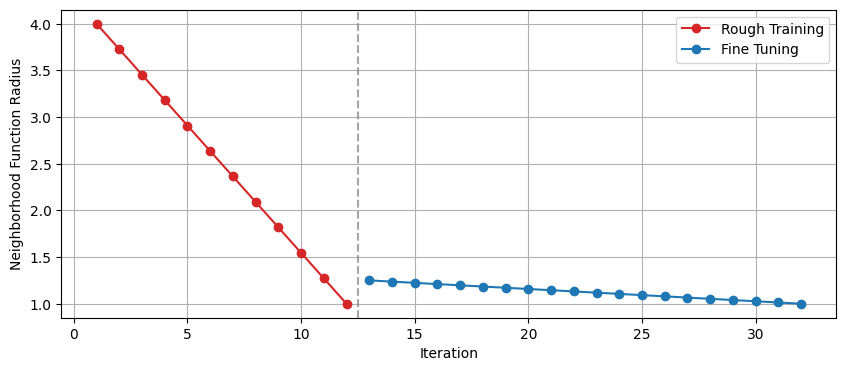

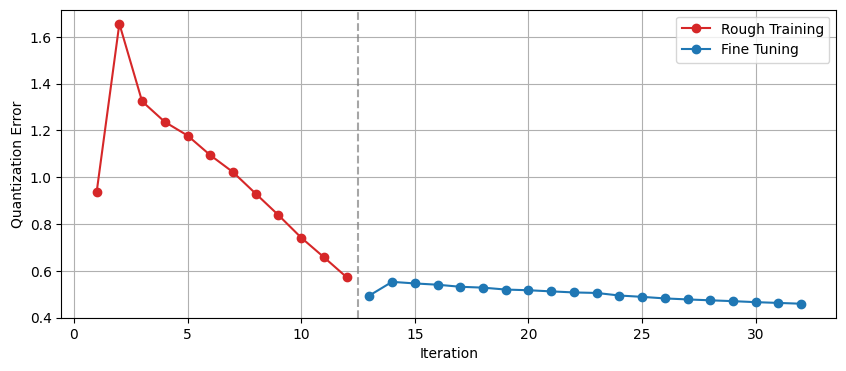

In [4]:
# Training of the SOM
som_iris.train(qe_plot=True, radius_plot=True, plot_figsize=(10,4))

In [5]:
# Visualization module
plot_iris = PlotFactory(som_iris)

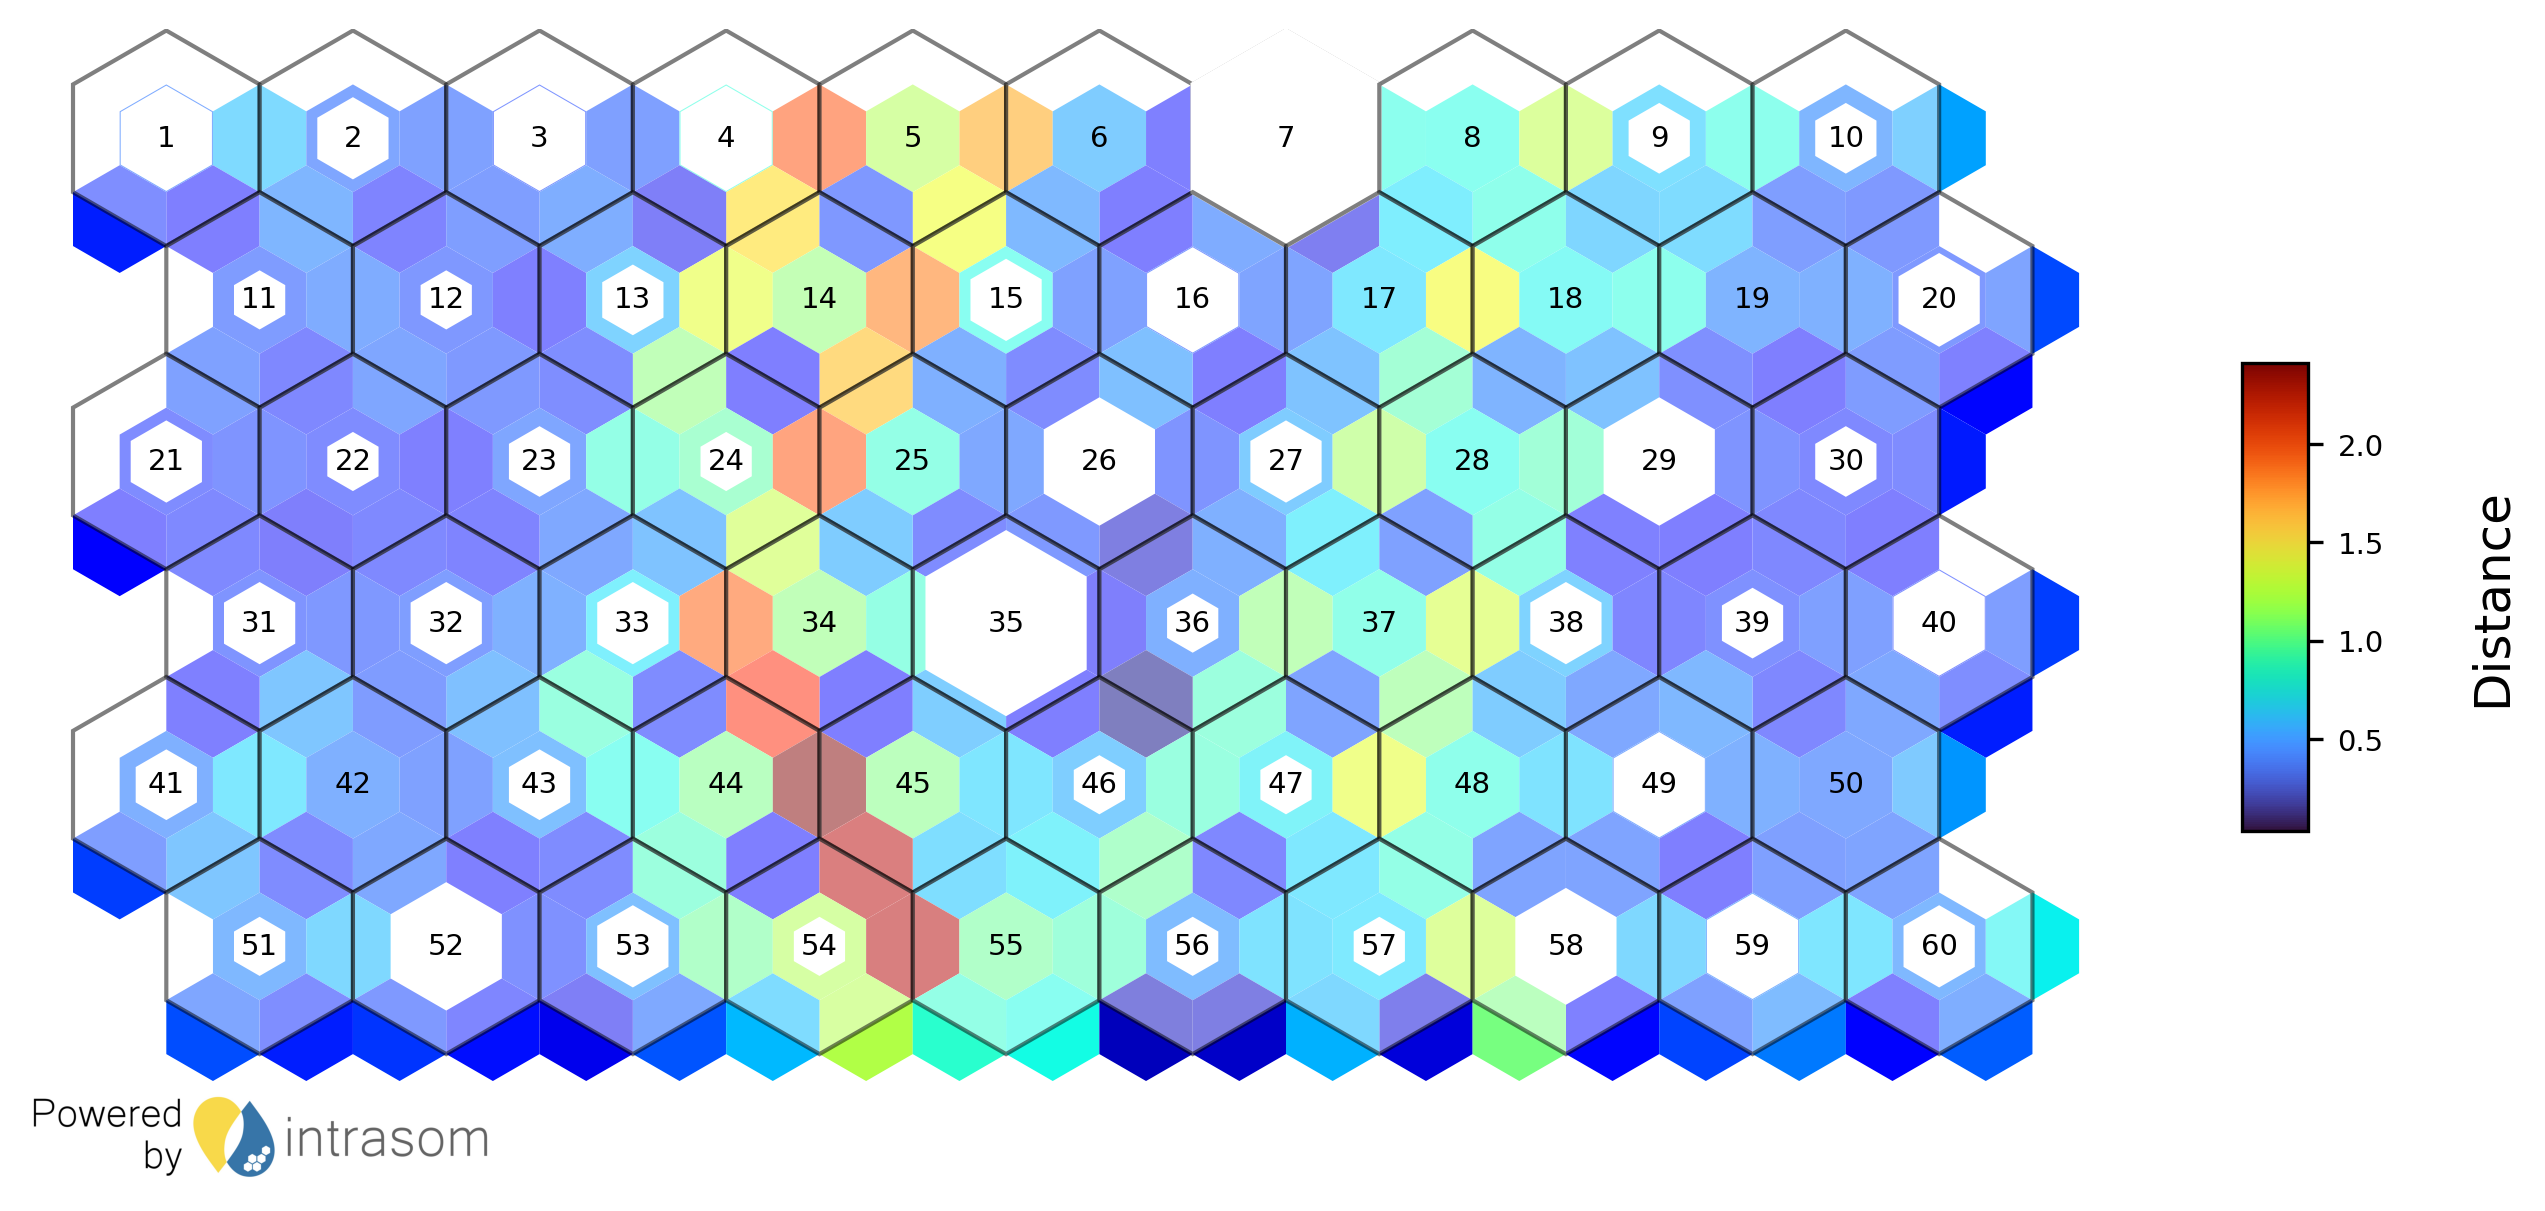

In [6]:
# U-matrix visualization: SOM space
plot_iris.plot_umatrix(
    figsize = (10,5),
    hits = True, # hits as white hexagons
    title = "",
    title_pad = 25,
    legend_title_size = 12,
    legend_ticks_size = 7,
    label_title_xy = (0,0.5),
    save = False,
    watermark_neurons=True, # template with the number of each neuron
    neurons_fontsize = 7)

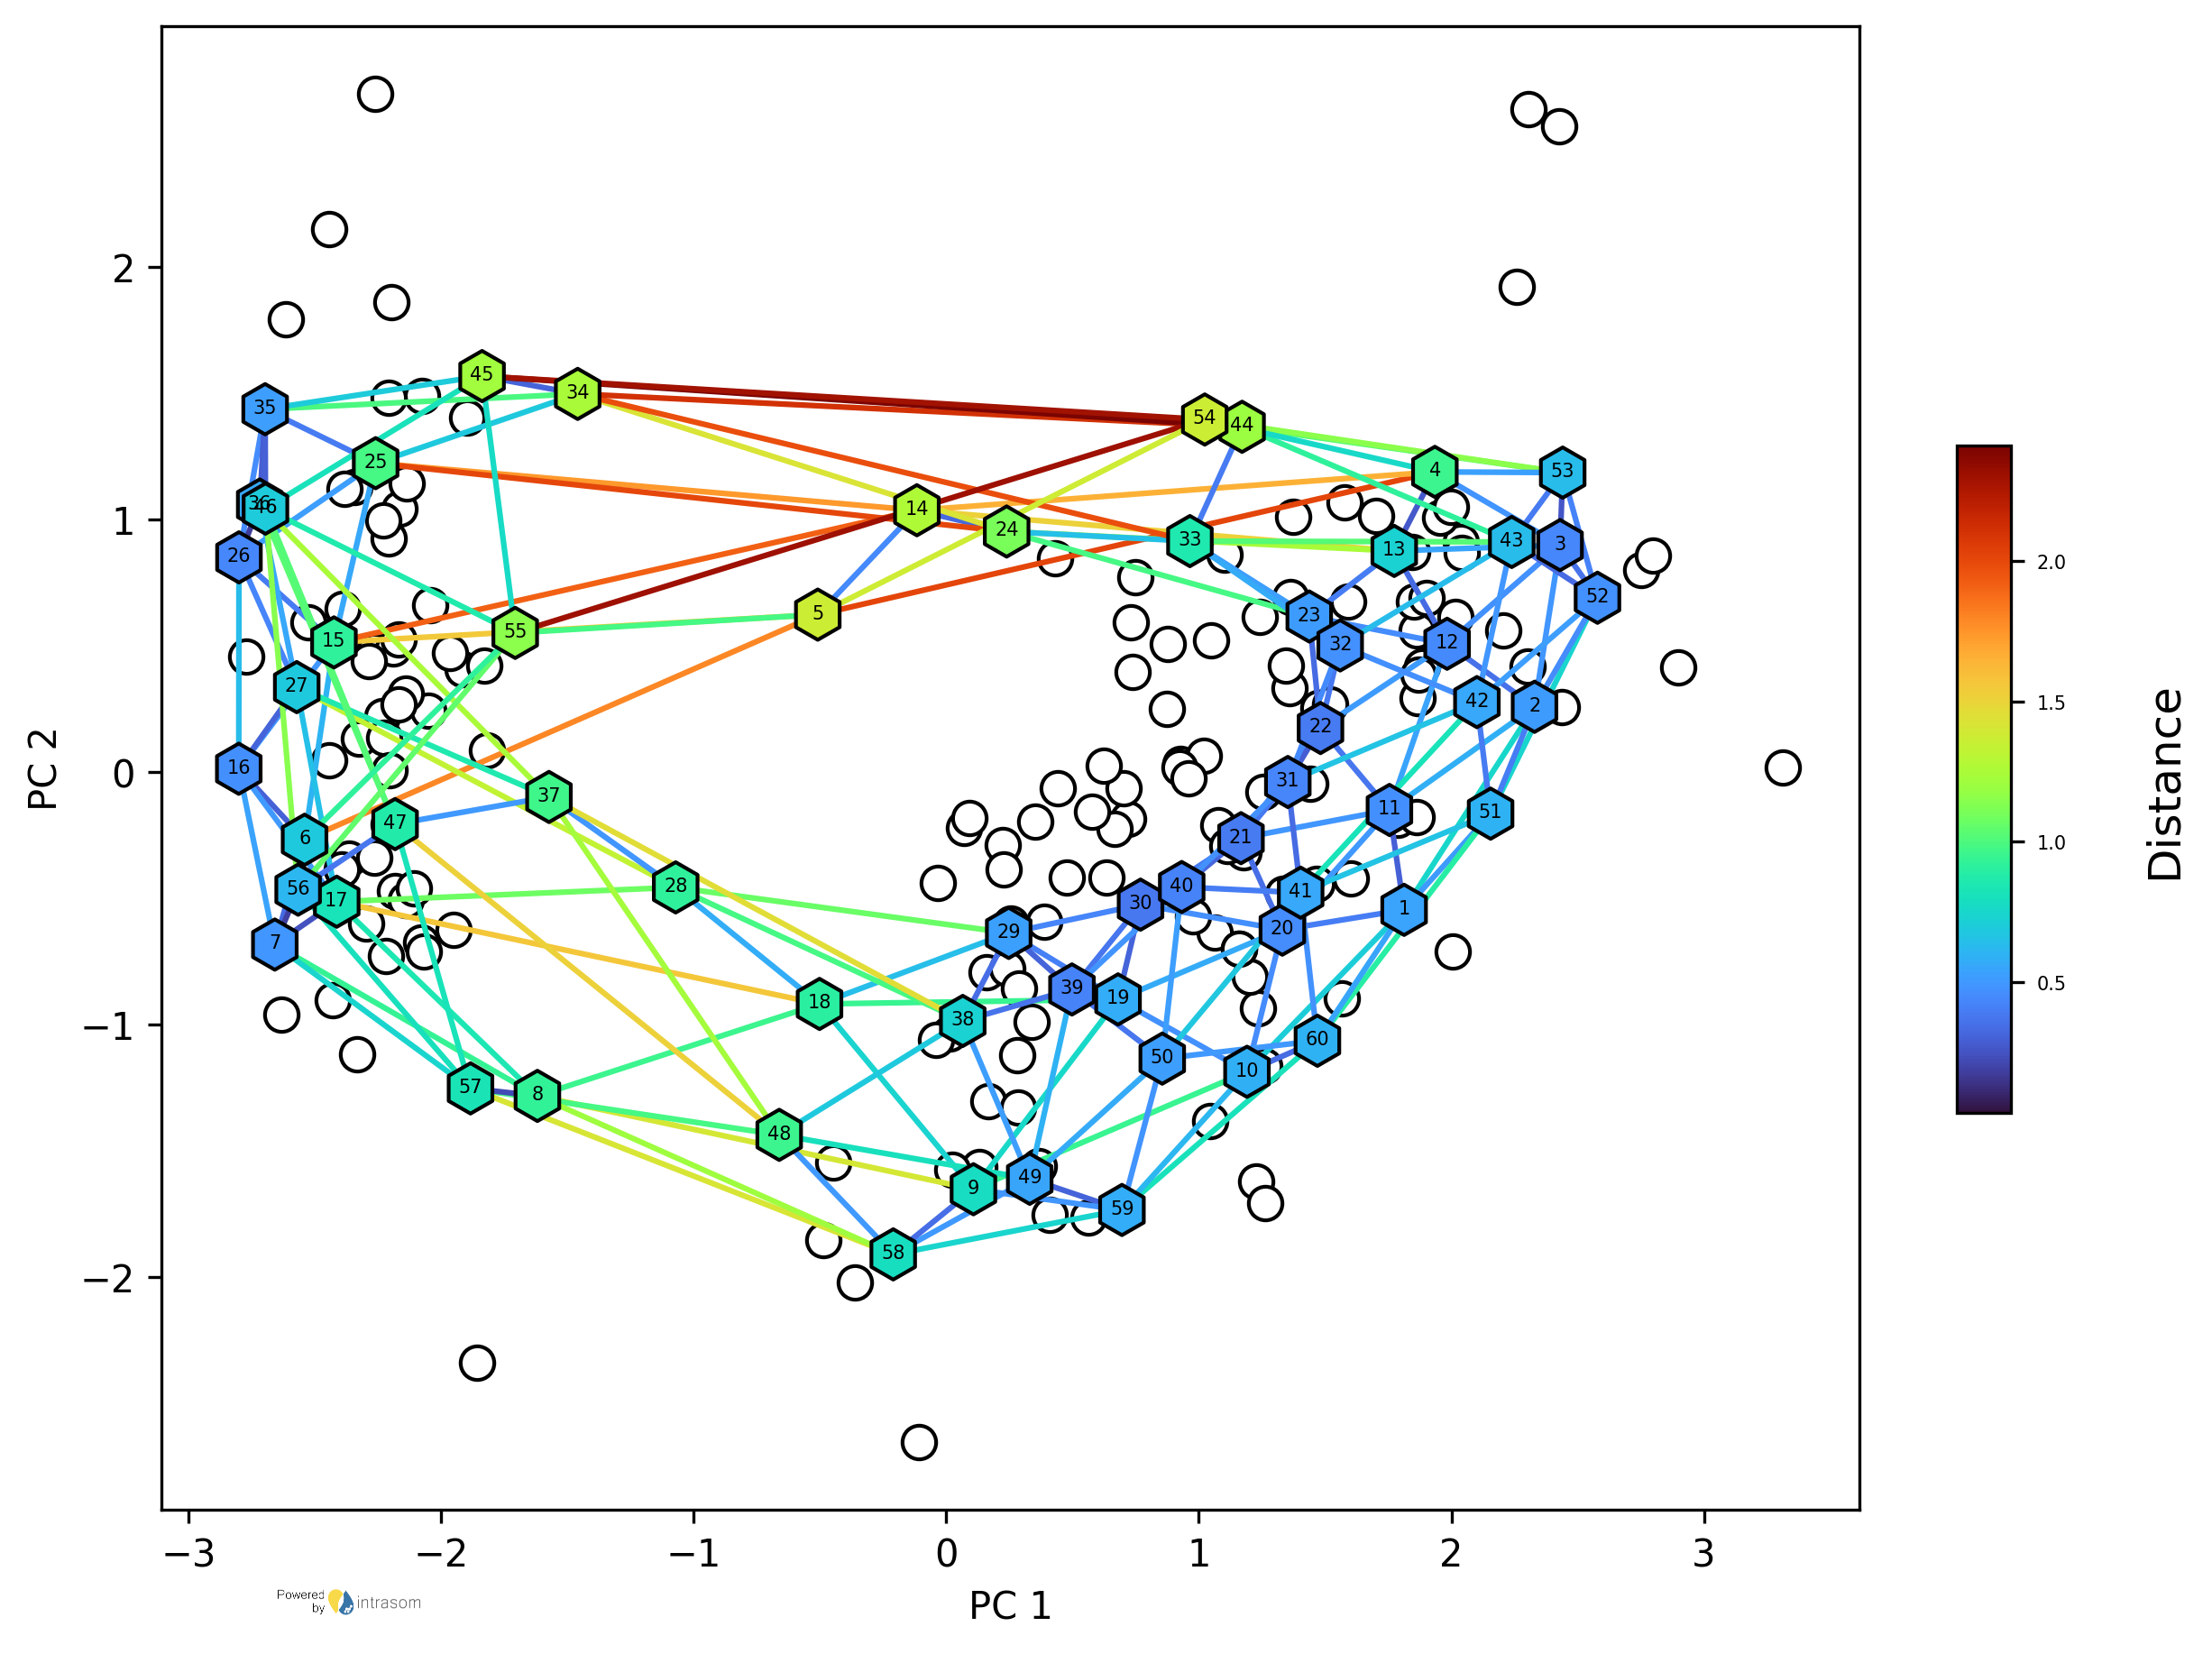

In [ ]:
# U-matrix visualization: PCA space
plot_iris.plot_som_pca(
    figsize=(9,9),
    normalization='var', # the same as before
    title="",
    legend_title_size = 12,
    show_samples = True,
    samples_size = 80, # white circles
    show_connections = True, # lines connecting neighboring neurons
    connections_linewidth = 1.5,
    show_neurons = True,
    neurons_size = 180, # hexagons
    watermark_neurons = True # neurons template
)

In [8]:
# Clustering module
clustering_iris = ClusterFactory(som_iris)
clusters_iris = clustering_iris.kmeans(k=3) # k = 3, since we know the iris species are setosa, versicolor and virginica

In [9]:
# Visualize the BMU of each sample and its corresponding cluster
clustering_iris.results_cluster(clusters_iris)

,BMU,Udist,Ret_x,Ret_y,Cub_x,Cub_y,Cub_z,B_sepal length (cm),B_sepal width (cm),B_petal length (cm),B_petal width (cm),3_clusters
0,26,0.057197,5,2,4,-6,2,5.117313,3.574564,1.522404,0.278612,3
1,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
2,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
3,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
4,26,0.057197,5,2,4,-6,2,5.117313,3.574564,1.522404,0.278612,3
...,...,...,...,...,...,...,...,...,...,...,...,...
145,2,0.131041,1,0,1,-1,0,6.737075,2.943227,5.627077,2.067965,1
146,60,0.216147,9,5,7,-12,5,6.178637,2.611870,4.915185,1.634545,2
147,12,0.067977,1,1,1,-2,1,6.599654,3.062248,5.389835,2.022213,1
148,4,0.582565,3,0,3,-3,0,6.661516,3.286167,5.430817,2.099059,1


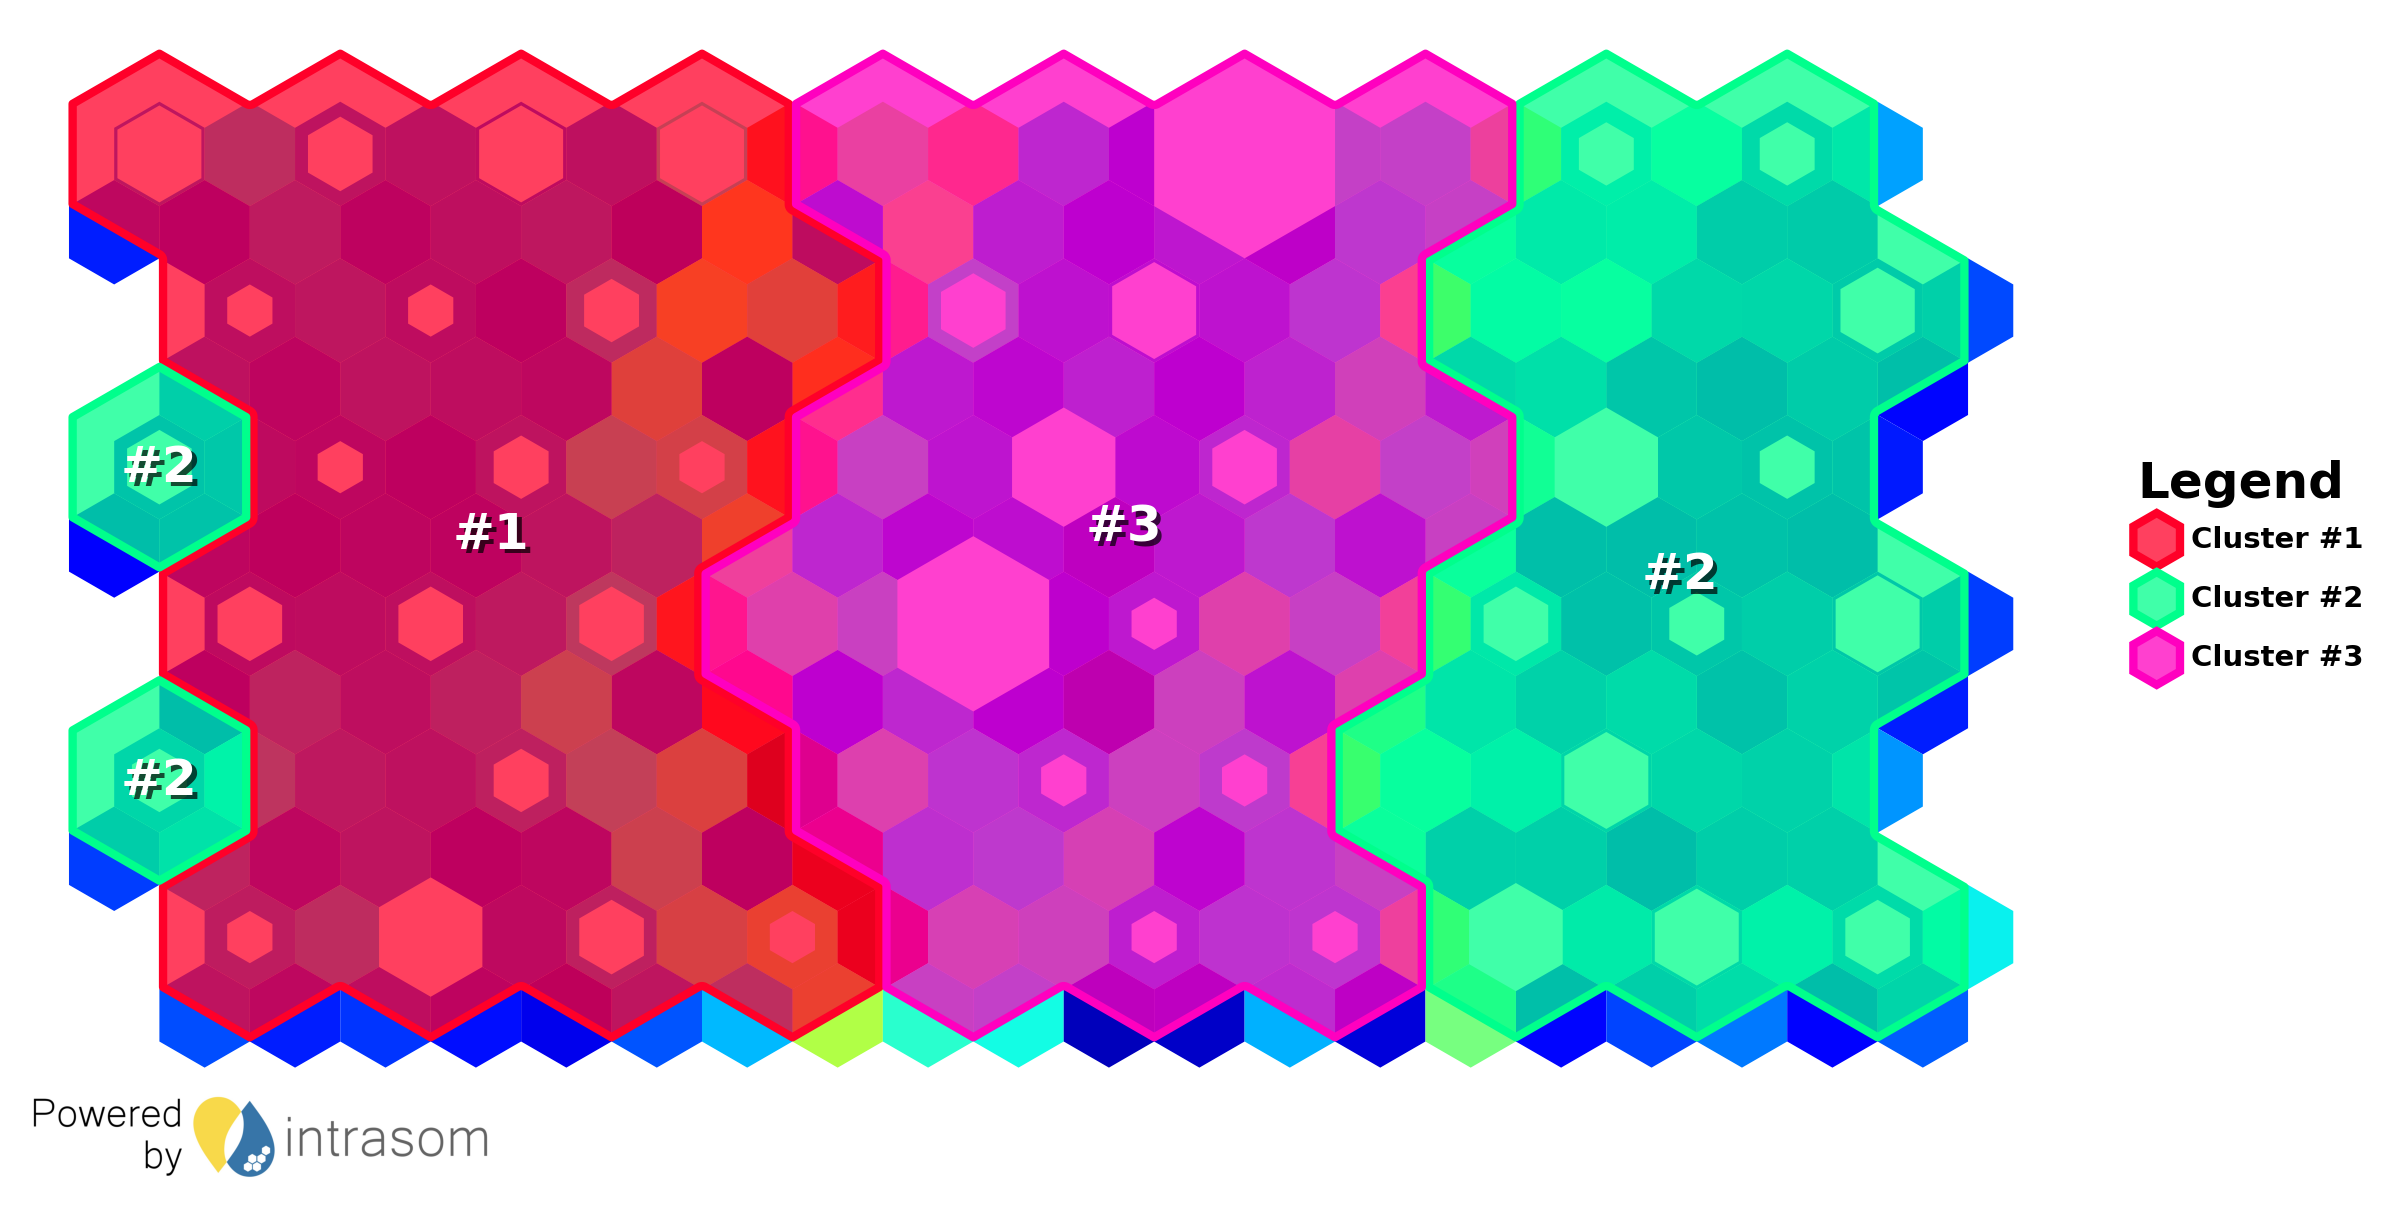

In [35]:
# Visualization of the clustered self-organized map
clustering_iris.plot_kmeans(
    figsize = (10,5),
    title = "",
    clusters = clusters_iris,
    title_size = 18,
    title_pad = 20,
    umatrix = True,
    colormap = "gist_rainbow",
    alfa_clust = 0.75,
    hits = True,
    legend_text_size = 7,
    cluster_outline = True,
    plot_labels = True)

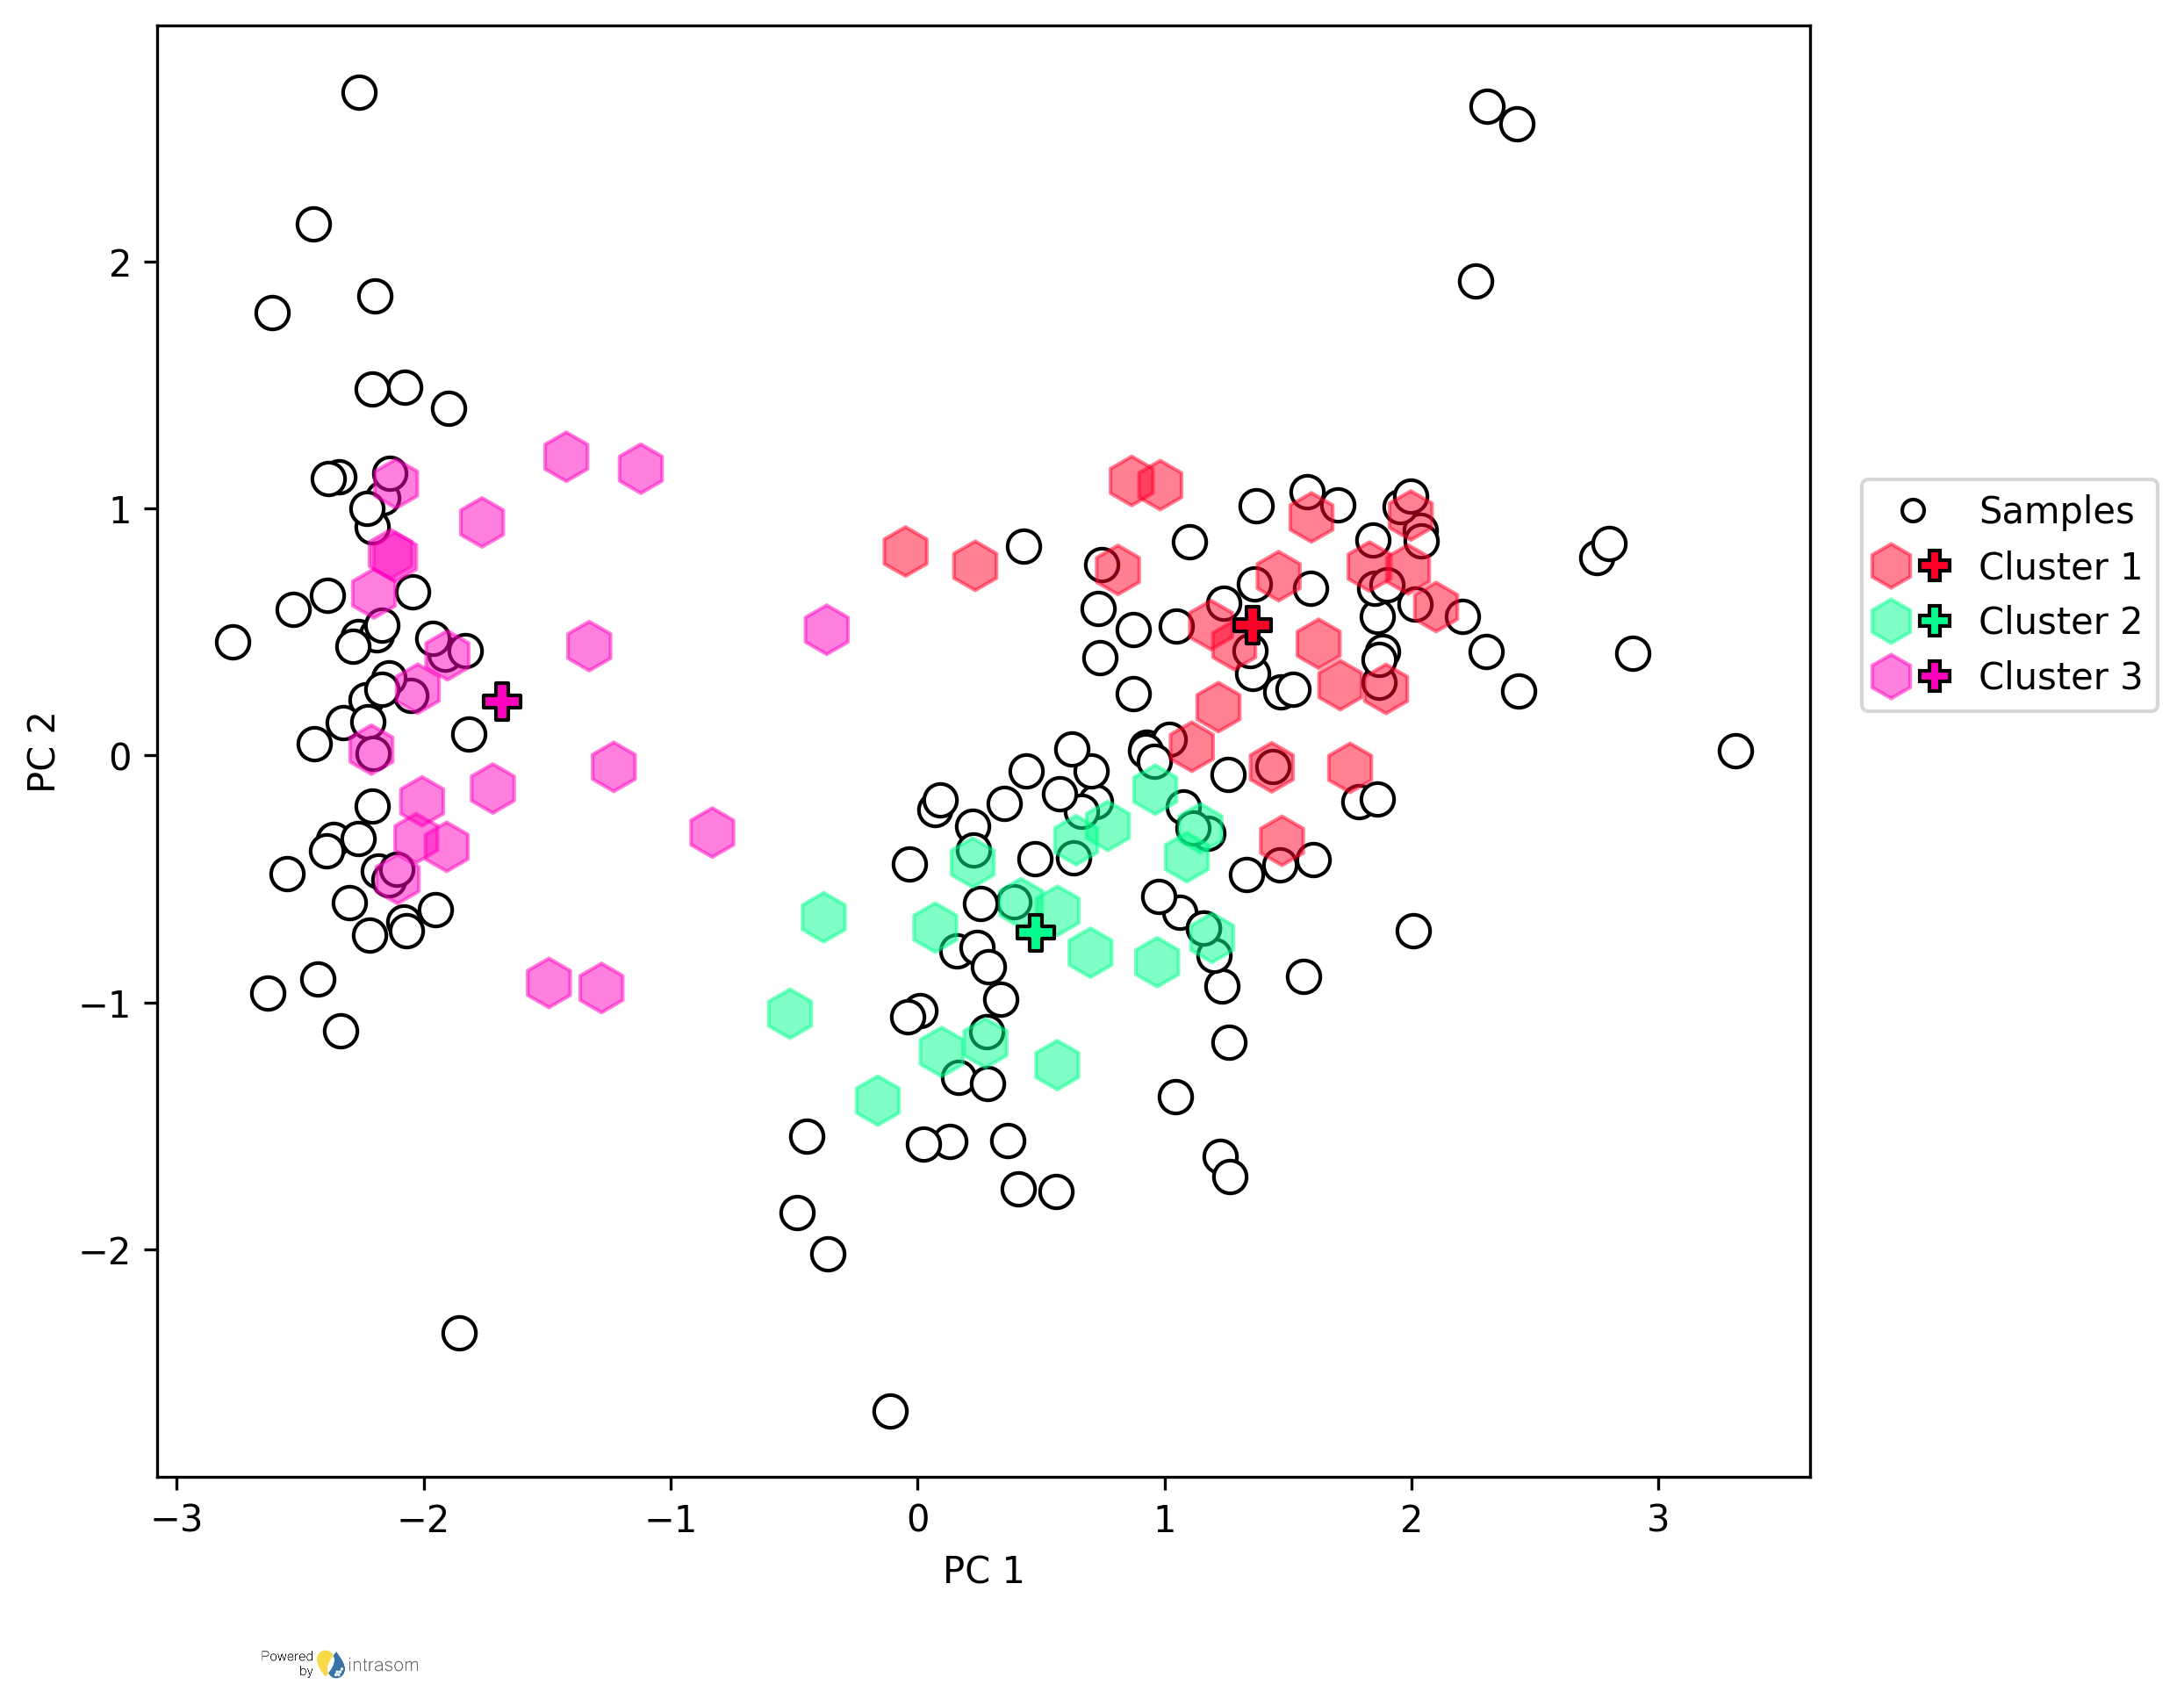

In [18]:
# Clusters of neurons in the PCA projection
clustering_iris.plot_clusters_pca(
    figsize = (9,9),
    normalization = 'var',
    title = '',
    show_samples = True,
    samples_size = 80,
    show_neurons=True,
    neurons_size = 180,
    show_centroids = True,
    centroids_size = 100,
    colormap='gist_rainbow',
    watermark_neurons=False,
    watermark_neurons_fontsize=5)

In [30]:
# Load cluster representativity module
representatives_iris = ClusterRepresentativity(clustering_iris)

# CMPF matrix, clusters weights and typical neurons of each cluster
neurons_responsibilities = representatives_iris.calculate_neurons_cmpf() # (n_neurons, n_clusters)
iris_clusters_weights = representatives_iris.clusters_weights
iris_typical_neurons = representatives_iris.cluster_representatives_indices
print(f'Weights of the clusters 1, 2 and 3, respectively: {iris_clusters_weights}')
print(f'Indices of the typical neurons of clusters 1, 2 and 3, respectively: {iris_typical_neurons}')

Weights of the clusters 1, 2 and 3, respectively: [0.36083252 0.43319984 0.20596763]
Indices of the typical neurons of clusters 1, 2 and 3, respectively: [54  9 35]


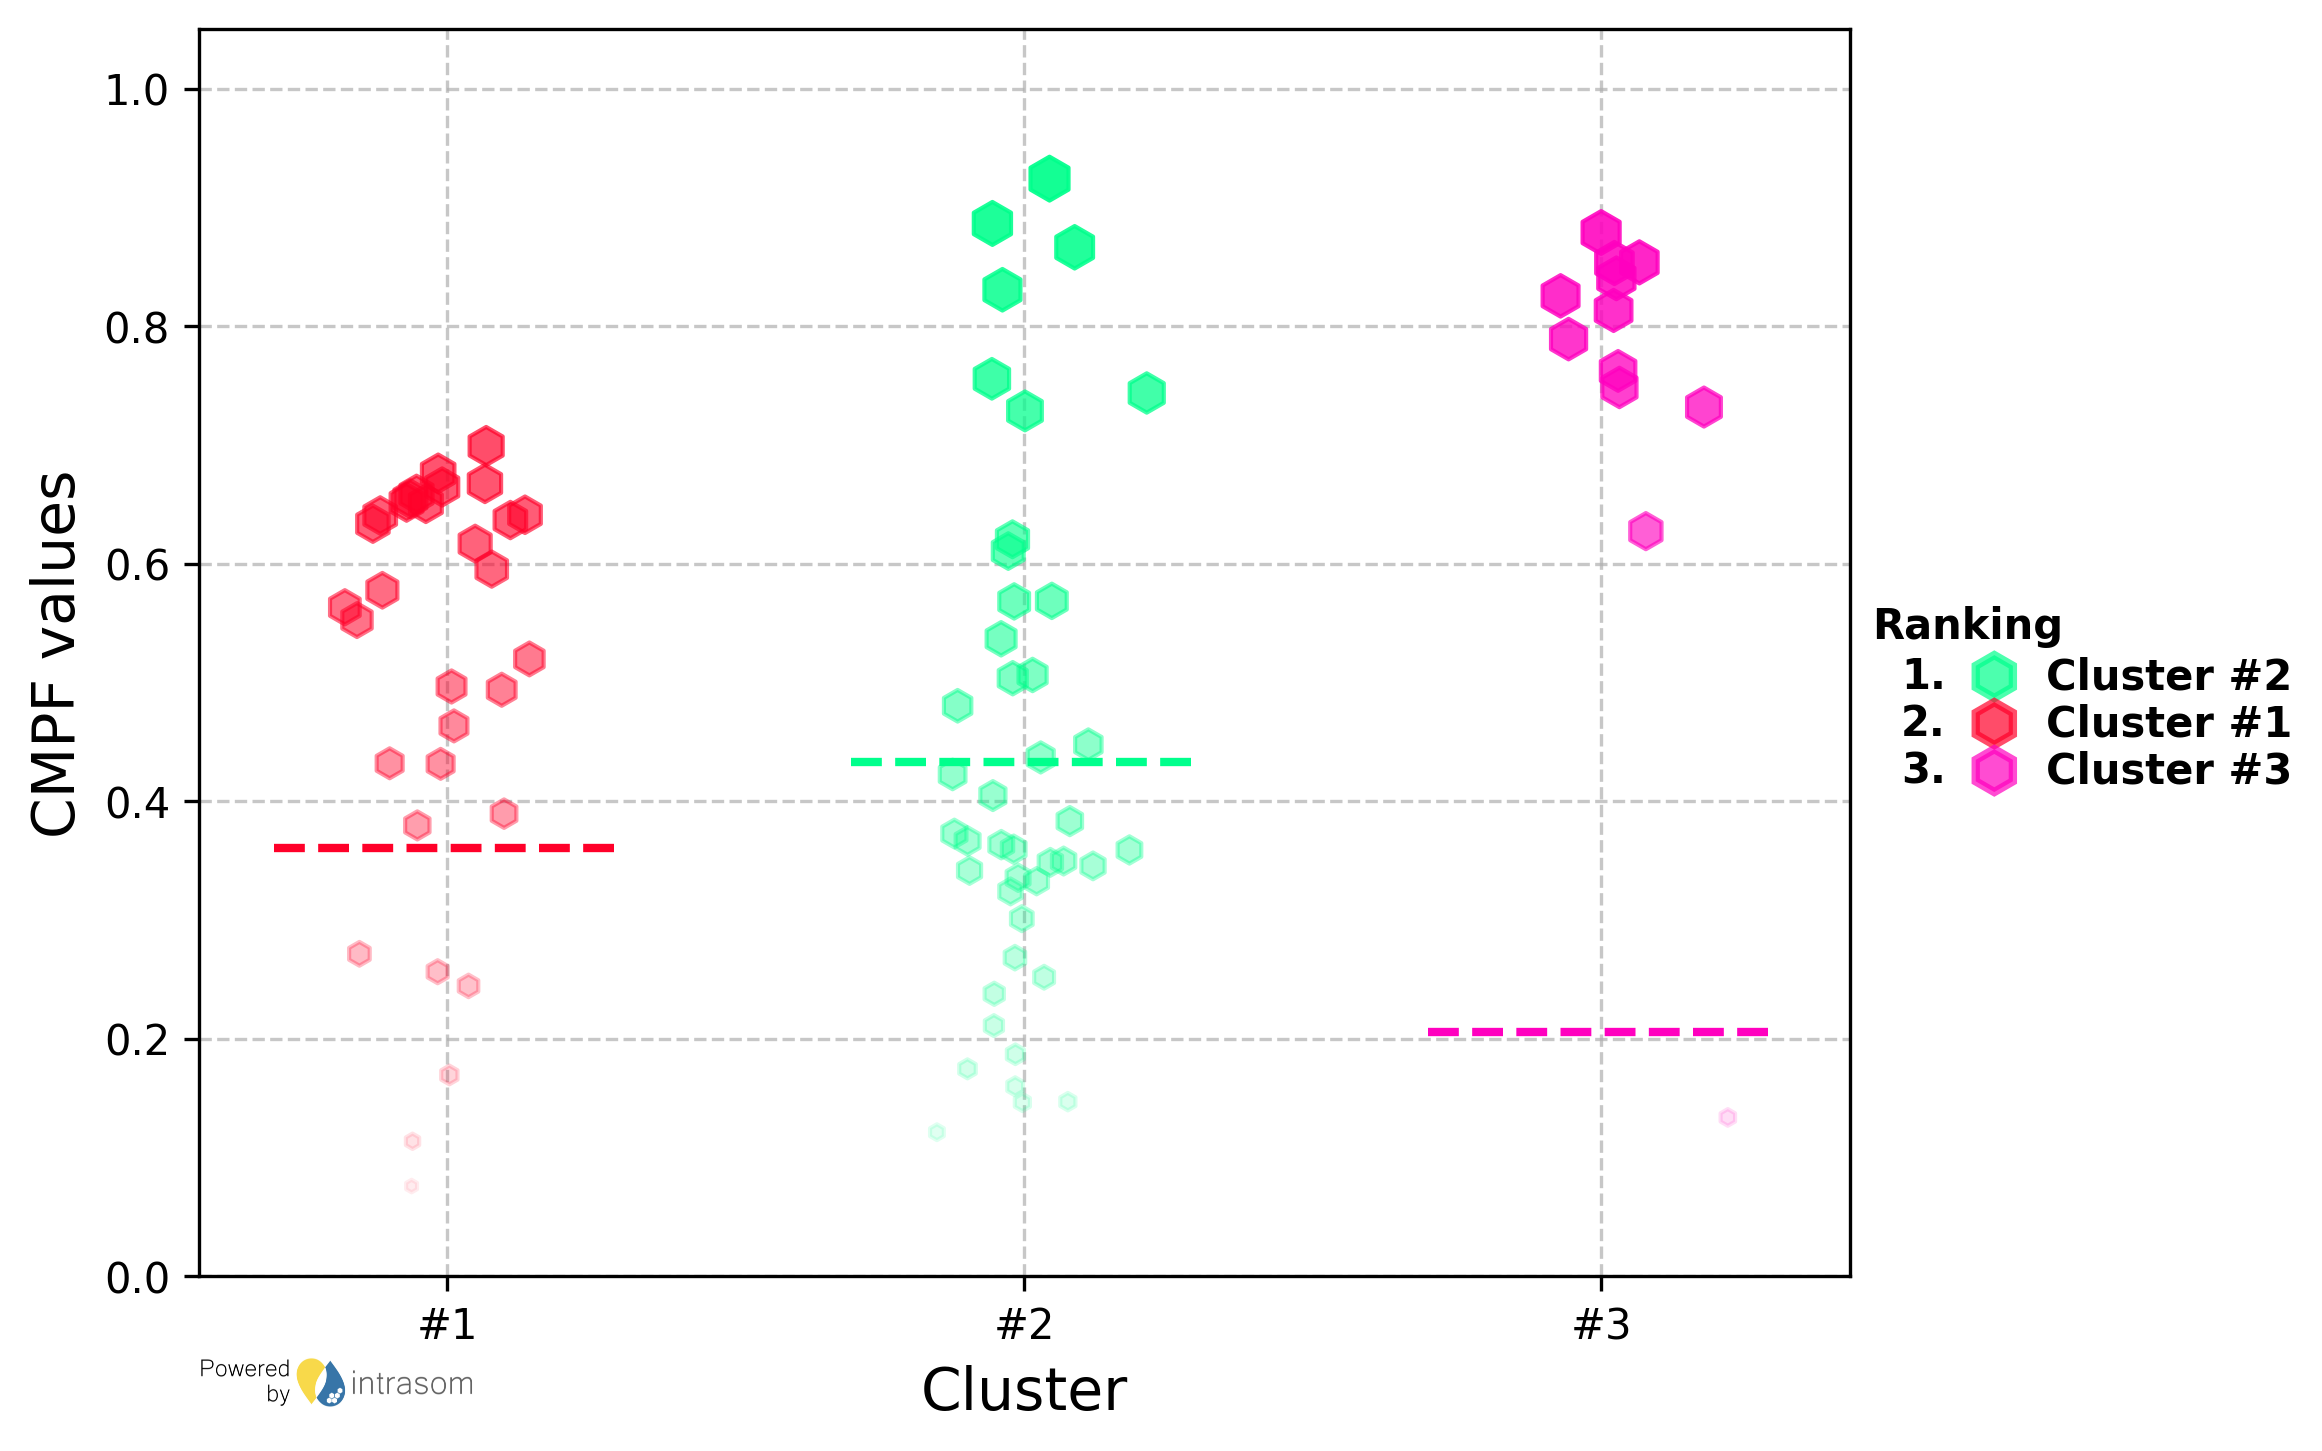

In [39]:
# It is possible to visualize the weights distribution in the jitterplot of the CMPF values of all neurons for each cluster
# Larger weights indicate that a cluster is close to a region with high concentration of neurons with more samples assigned to them, while smaller weights indicate that a cluster is isolated from these regions
representatives_iris.cmpf_jitter_plot(
    plot_width = 8,
    title = "",
    legend_title = "Ranking",
    yrange = [0.0,1.05],
    xlabel_size = 14,
    ylabel_size = 14,
    legend_title_size = 10,
    legend_text_size = 10,
    watermark_neurons = False)

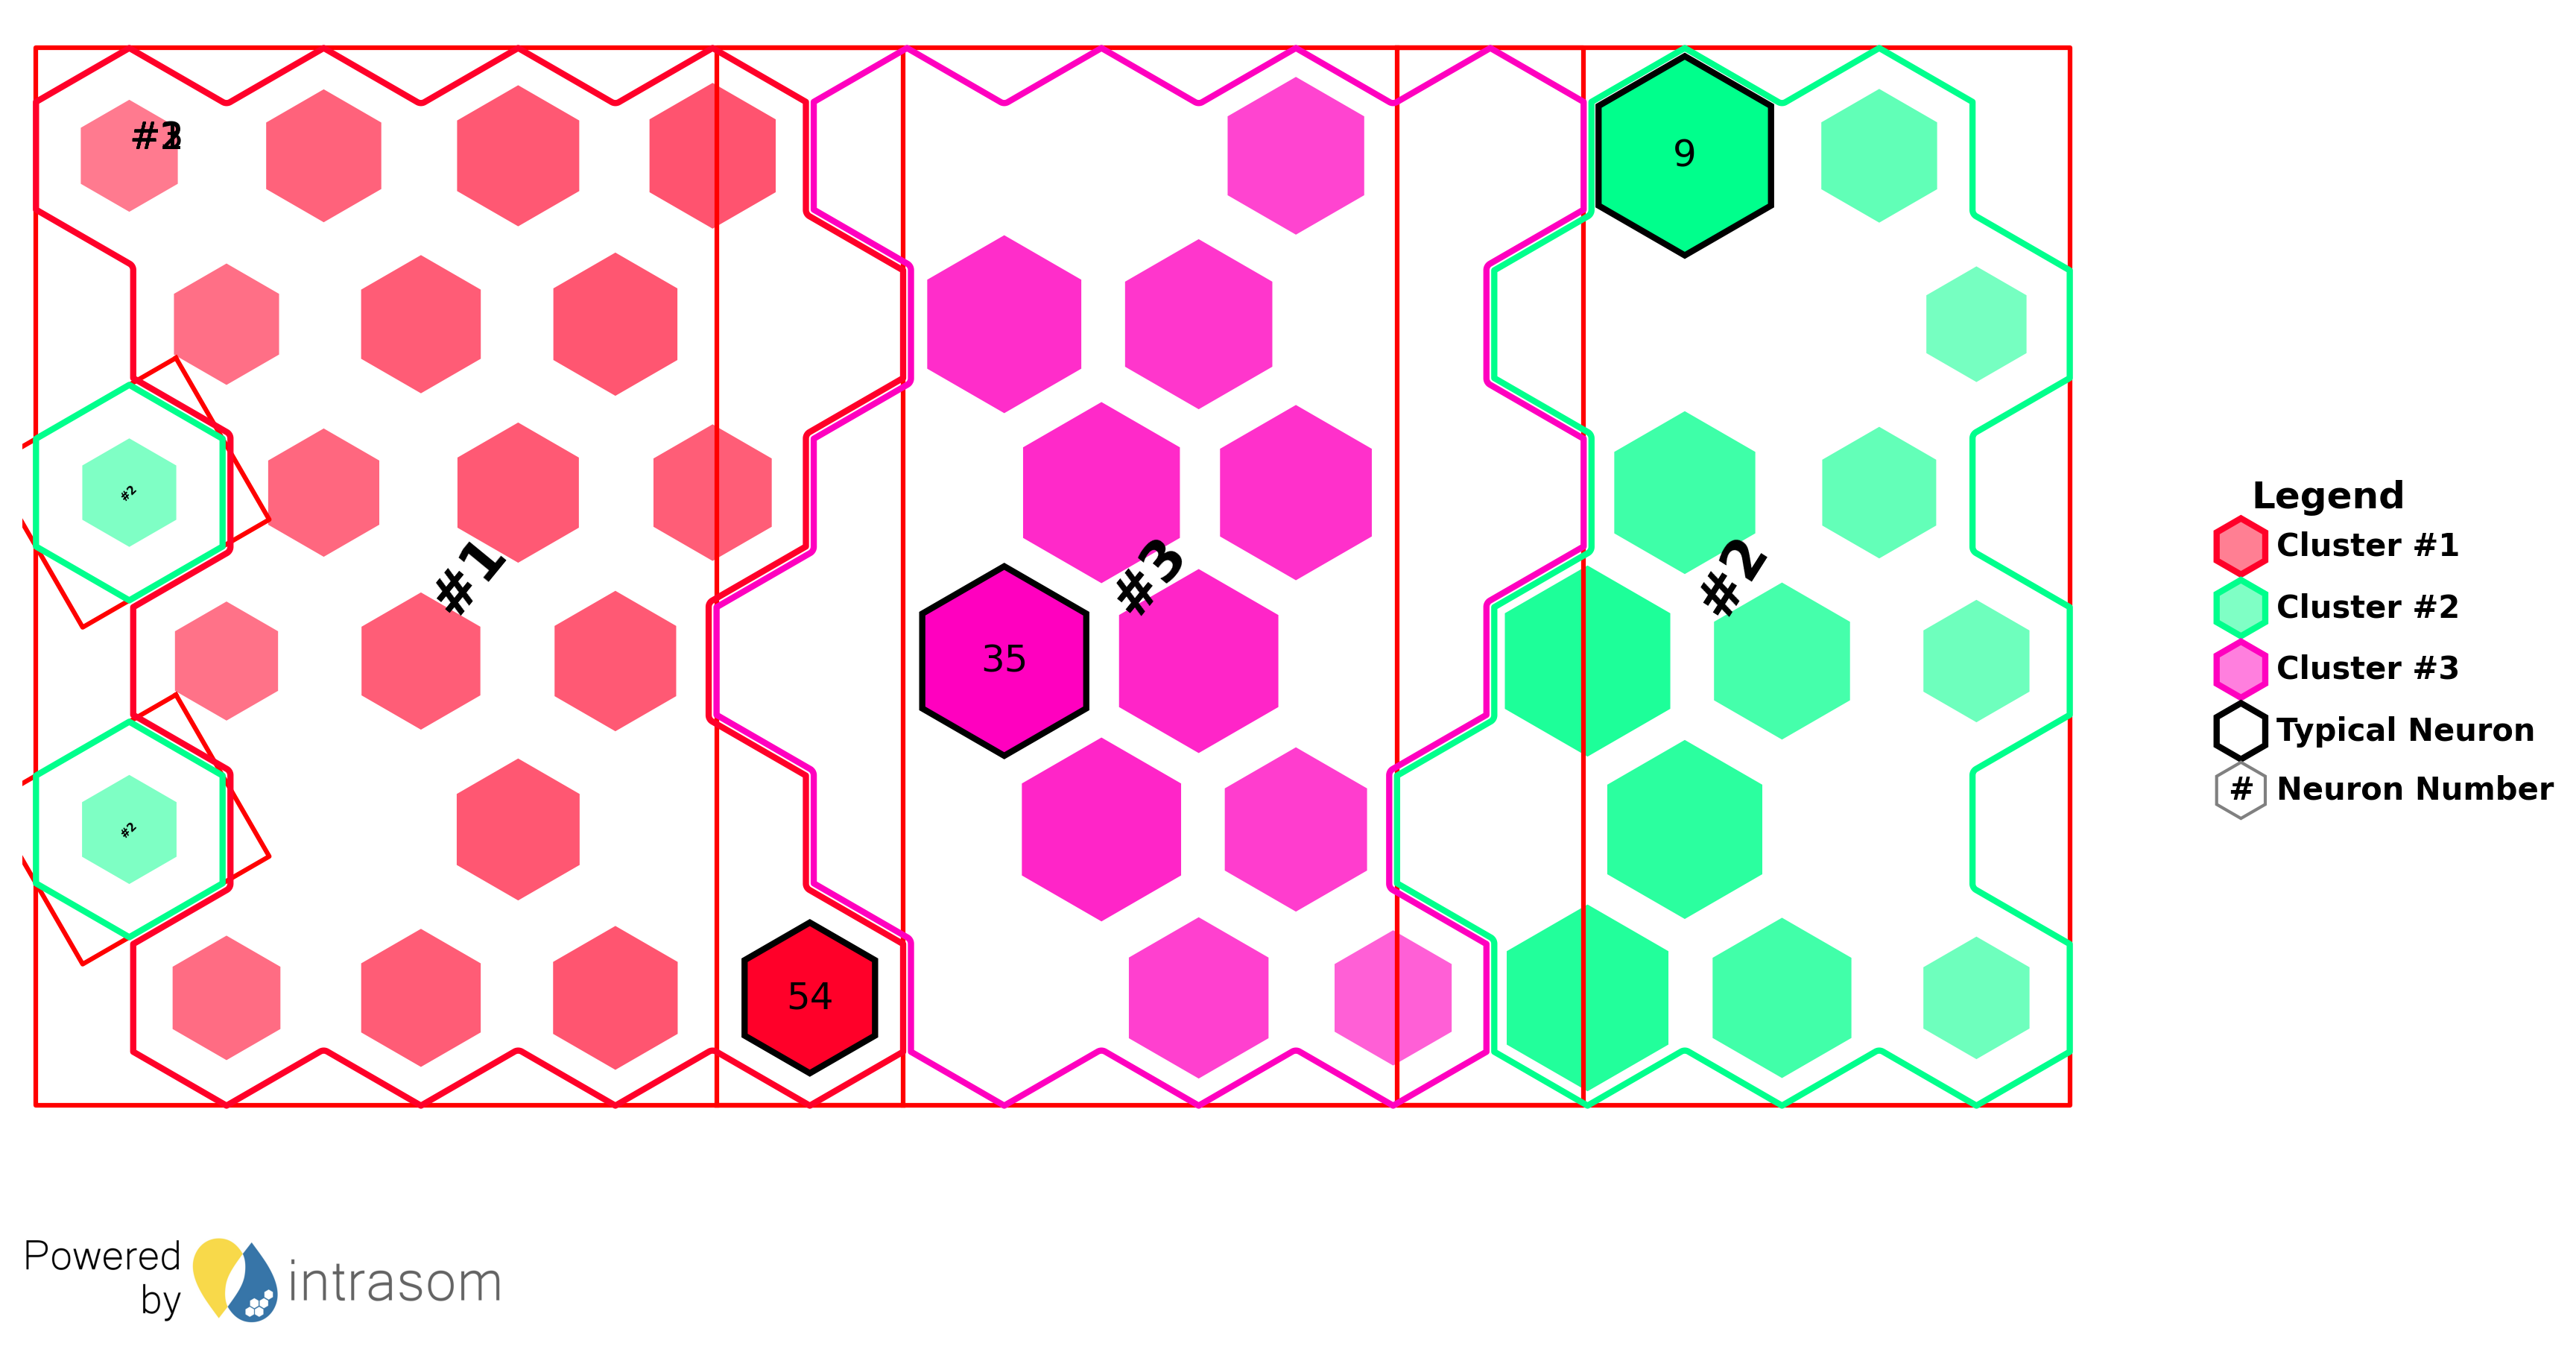

In [ ]:
# In the SOM space, we can verify these regions by plotting the maximum CMPF value of each neuron (improve this code)
representatives_iris.cmpf_som_plot(
    figsize = (14,8),
    watermark_neurons = False,
    watermark_typical_neurons = True,
    colormap = "gist_rainbow",
    title = "",
    plot_labels = True,
    auto_adjust_text = True,
    clusterout_maxtext_size = 12,
    alfa_clust_legend = 0.5,
    neuron_number_label = "Neuron Number",
    typical_neuron_label = "Typical Neuron")

In [ ]:
# Now, to select typical samples we can use different criteria obtained with the typical_sample_analysis method
typical_iris_analysis = representatives_iris.typical_sample_analysis()
typical_iris_analysis

,Sample_index,BMU,Cluster,CMPF_value,Silhouette,Samples_BMU_dists,Cluster_order
0,0,26,3,0.840185,0.732211,0.213190,3
1,1,7,3,0.731809,0.563684,0.304371,3
2,2,7,3,0.731809,0.674515,0.309147,3
3,3,7,3,0.731809,0.616640,0.247186,3
4,4,26,3,0.840185,0.726576,0.197945,3
...,...,...,...,...,...,...,...
145,145,2,1,0.616833,0.462843,0.413896,2
146,146,60,2,0.568609,0.202732,0.460828,1
147,147,12,1,0.641123,0.383029,0.218197,2
148,148,4,1,0.676040,0.379711,0.672048,2


In [ ]:
# These criteria are:
print(f'Samples with BMUs with highest CMPF values of each cluster: missing implementation.')
print(f'Samples with highest Silhouette Coefficient (SC) values of each cluster: {representatives_iris.sc_typical_samples_indices.values}')
print(f'Samples closest to the typical neuron of each cluster: {representatives_iris.cmpf_dists_typical_samples_indices.values}')

# Plot a PCA visualization comparing the three

Samples with BMUs with highest CMPF values of each cluster: missing implementation.
Samples with highest Silhouette Coefficient (SC) values of each cluster: [120  89   0]
Samples closest to the typical neuron of each cluster: [59 48 56]


In [ ]:
# Plot the Silhouette plot for the CMPF, SC (separating for each cluster) and Samples_BMU_dists (ordering by cluster then by BMU)